# VocEd Lab 1 — Exploring the Cell Images

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/emilsar/VocEd/blob/main/Labs/Lab1_exploratory_analysis.ipynb)

The goal of the whole course is to measure the **nucleus-to-cytoplasm (N/C) ratio** of
urothelial cells, a key number pathologists use to spot cancer.  Before we build anything
that *predicts*, we need to know our data: how it is stored, what it looks like, and how
the three kinds of pixel (background, cytoplasm, nucleus) differ from one another.

This lab is **purely exploratory**.  We will not segment anything yet.  That starts in Lab 2.

By the end of this lab you will be able to:
- Load the dataset and explain what every number in its shape means.
- Pull out single images, single colour channels, and single pixels.
- Display images and masks correctly, and lay a mask over an image.
- Count how many pixels of each class the dataset contains, and compute the true N/C ratio.
- Convert colour images to grayscale by hand.
- Compare the brightness of nucleus, cytoplasm, and background pixels.

**Textbook:** [Introduction to Image Processing, Segmentation, and Deep Learning](https://obooks.tech/imageprocessing/),
Chapters 1 and 2.

---

### How the puzzles work 🧩

Throughout the lab you will find **puzzles**: code cells with one or more blanks written as `___`.

1. Replace every `___` with the right code.
2. Run the cell.  If you got it right you will see a ✅ message.
3. Stuck?  Each puzzle links to the section of the textbook that explains the idea, and has
   **hints** you can click open.  Try the book first, then the hints.

If you run a puzzle cell *before* filling it in, you will see
`NameError: name '___' is not defined`.  That is expected — it just means a blank is still empty.

## 0. Setup — Get the Data

The cell below copies the VocEd repository (which includes the images) into your Colab
session.  Run it once per session.

In [1]:
!git clone https://github.com/emilsar/VocEd.git
%cd VocEd

Cloning into 'VocEd'...
remote: Enumerating objects: 688, done.
remote: Counting objects: 100% (67/67), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 688 (delta 42), reused 60 (delta 39), pack-reused 621 (from 2)
Receiving objects: 100% (688/688), 40.38 MiB | 9.86 MiB/s, done.
Resolving deltas: 100% (400/400), done.
Updating files: 100% (420/420), done.
/content/VocEd


## 1. Loading the Data

The dataset has **200 images** and **200 masks**.  A *mask* is the answer key: an image of
the same size in which every pixel holds a label instead of a colour.

| Folder | Shape of one file | Type | Meaning |
|---|---|---|---|
| `imagedata/X/` | `(3, 256, 256)` | `float32` | colour image: 3 channels (R, G, B), values from 0 to 1 |
| `imagedata/y/` | `(256, 256)` | `int64` | mask: one label per pixel |

Mask labels: `0` = background (empty glass) · `1` = cytoplasm · `2` = nucleus

We stack all 200 images into one big array `X` and all masks into `y`.  Stacking adds a
new first axis — the image number — so `X` becomes **four-dimensional**.  This
"batch" layout is exactly the one described in
[§1.5 Four-Dimensional Arrays: Batch Processing](https://obooks.tech/imageprocessing/chapter1.html#four-dimensional-arrays-batch-processing).

In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = np.stack([np.load(f"imagedata/X/{i}.npy") for i in range(200)])
y = np.stack([np.load(f"imagedata/y/{i}.npy") for i in range(200)])

print("X shape:", X.shape, "  dtype:", X.dtype)
print("y shape:", y.shape, "  dtype:", y.dtype)
print("Smallest and largest value in X:", X.min(), X.max())
print("Labels that appear in y:", np.unique(y))

X shape: (200, 3, 256, 256)   dtype: float32
y shape: (200, 256, 256)   dtype: int64
Smallest and largest value in X: 0.0 1.0
Labels that appear in y: [0 1 2]


Read the shape `(200, 3, 256, 256)` from left to right:
**200** images · **3** colour channels · **256** rows · **256** columns.

Putting the channels *first* is called **channels-first** (or CHW) order.  It is what
PyTorch uses, and we will meet it again when we build neural networks.

### 🧩 Puzzle 1 — One image out of the batch

Pull image number 7 and its mask out of the batch.  Then use an array attribute to print
how many numbers a single image holds.

📖 Book: [§1.4.2 Three-Dimensional Indexing](https://obooks.tech/imageprocessing/chapter1.html#three-dimensional-indexing) and
[§1.2.1 Fundamental Concepts](https://obooks.tech/imageprocessing/chapter1.html#fundamental-concepts) (array attributes like `.shape`, `.ndim`, `.size`)

<details><summary><b>💡 Hint 1</b> (click to open)</summary>

Indexing only the first axis of a 4-D array hands you back everything else: `X[5]` is the whole of image 5.

</details>

<details><summary><b>💡 Hint 2</b> (click to open)</summary>

The attribute that counts *all* the numbers in an array (not its shape) is `.size`. For one image it should be 3 × 256 × 256.

</details>

In [5]:
img7  = X[7]
mask7 = y[7]

print("img7  shape:", img7.shape)
print("mask7 shape:", mask7.shape)
n_numbers = img7.size
print("Numbers in one image:", n_numbers)

# ── Check ──
assert img7.shape == (3, 256, 256) and np.array_equal(img7, X[7]), "img7 should be image number 7"
assert mask7.shape == (256, 256) and np.array_equal(mask7, y[7]), "mask7 should be mask number 7"
assert n_numbers == 196608, "Look for the attribute that counts every element"
print("✅ Puzzle 1 solved!")

img7  shape: (3, 256, 256)
mask7 shape: (256, 256)
Numbers in one image: 196608
✅ Puzzle 1 solved!


## 2. Looking at the Colour Channels

A colour image is three grayscale images stacked on top of each other: one for how much
**red** light each pixel has, one for **green**, one for **blue**.  In channels-first order
the channel is the first axis of `img7`.

### 🧩 Puzzle 2 — Split the channels

Pull the red, green and blue channels out of `img7`.  Each one should be a `(256, 256)` array.

📖 Book: [§1.4.5 Channel Manipulation](https://obooks.tech/imageprocessing/chapter1.html#channel-manipulation)

<details><summary><b>💡 Hint</b> (click to open)</summary>

Channels are numbered from 0 in the order R, G, B.  Since the channel is the *first* axis of `img7`, a single index picks one out.

</details>

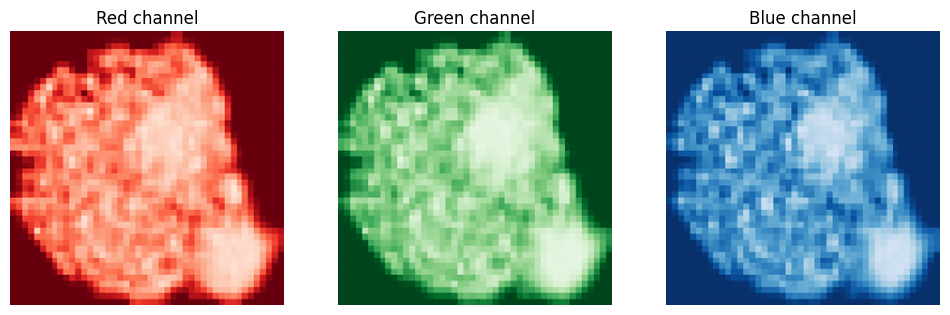

✅ Puzzle 2 solved!


In [9]:
R = img7[0]
G = img7[1]
B = img7[2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(R, cmap='Reds', vmin=0, vmax=1)
axes[0].set_title('Red channel')
axes[1].imshow(G, cmap='Greens', vmin=0, vmax=1)
axes[1].set_title('Green channel')
axes[2].imshow(B, cmap='Blues', vmin=0, vmax=1)
axes[2].set_title('Blue channel')
for ax in axes:
    ax.axis('off')
plt.show()

# ── Check ──
assert R.shape == (256, 256), "R should be a single 256 × 256 channel"
assert np.array_equal(R, X[7, 0]) and np.array_equal(G, X[7, 1]) and np.array_equal(B, X[7, 2]), \
    "Check the order: red, green, blue"
print("✅ Puzzle 2 solved!")

Notice we passed `vmin=0, vmax=1` to every panel.  Without it, `imshow` stretches each
panel to its own darkest and brightest value, and the three panels could not be compared
fairly.  See [§2.3.4 Important Considerations](https://obooks.tech/imageprocessing/chapter2.html#important-considerations).

**Think about it:** in which channel do the nuclei look darkest compared with the cytoplasm?
In which channel is the difference weakest?  Keep your answer in mind — it matters when we
turn colour into a single grayscale value in Section 5.

## 3. Displaying Images and Masks

### 🧩 Puzzle 3 — From channels-first to channels-last

Matplotlib's `imshow` wants a colour image shaped `(rows, columns, 3)` — the channel
*last*.  Ours is `(3, rows, columns)`.  Rearrange the axes with `.transpose()`.

📖 Book: [§1.4.6 Reshaping and Transposing](https://obooks.tech/imageprocessing/chapter1.html#reshaping-and-transposing) and
[§2.1.4 Array Shape and Color Channels](https://obooks.tech/imageprocessing/chapter2.html#array-shape-and-color-channels)

<details><summary><b>💡 Hint 1</b> (click to open)</summary>

`.transpose(a, b, c)` builds a new array whose axis 0 is old axis `a`, axis 1 is old axis `b`, and axis 2 is old axis `c`.

</details>

<details><summary><b>💡 Hint 2</b> (click to open)</summary>

Old axes: 0 = channel, 1 = rows, 2 = columns.  New order wanted: rows, columns, channel.

</details>

New shape: (256, 256, 3)


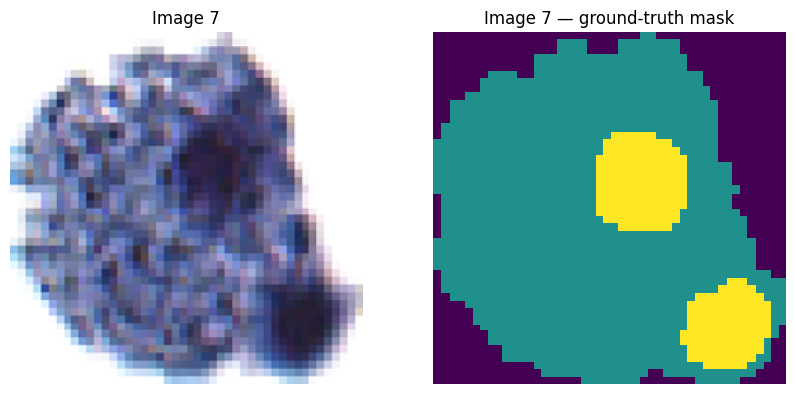

✅ Puzzle 3 solved!


In [13]:
img7_hwc = img7.transpose(1,2,0)
print("New shape:", img7_hwc.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img7_hwc)
axes[0].set_title('Image 7')
axes[1].imshow(mask7, cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
axes[1].set_title('Image 7 — ground-truth mask')
for ax in axes:
    ax.axis('off')
plt.show()

# ── Check ──
assert img7_hwc.shape == (256, 256, 3), "The channel axis should end up last"
assert np.array_equal(img7_hwc[:, :, 0], img7[0]), "Rows and columns should stay in their original order"
print("✅ Puzzle 3 solved!")

Two details in the mask plot are worth knowing:

- **`vmin=0, vmax=2`** pins the colours to the labels, so background is always purple,
  cytoplasm teal and nucleus yellow, whatever labels a particular mask contains.
- **`interpolation='nearest'`** stops matplotlib from blending neighbouring pixels when it
  resizes the picture for the screen.  Blending is fine for photos, but a mask holds labels:
  a pixel halfway between "background" (0) and "nucleus" (2) is **not** "cytoplasm" (1).
  See [§2.2.3 Nearest Neighbor Interpolation](https://obooks.tech/imageprocessing/chapter2.html#nearest-neighbor-interpolation).

Here are a few more images and their masks:

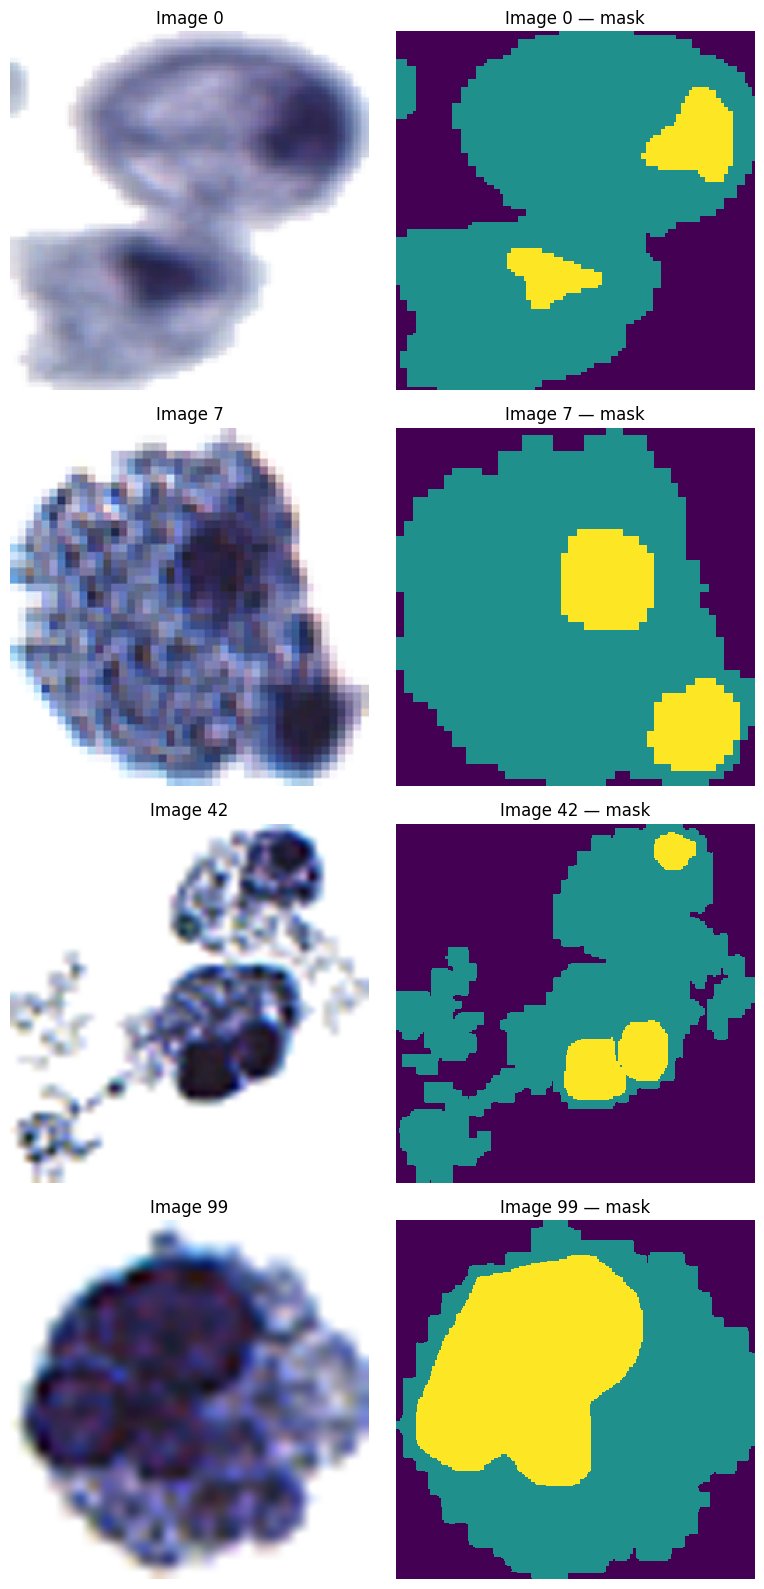

In [14]:
fig, axes = plt.subplots(4, 2, figsize=(8, 16))

for row, idx in enumerate([0, 7, 42, 99]):
    axes[row, 0].imshow(X[idx].transpose(1, 2, 0))
    axes[row, 0].set_title(f"Image {idx}")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(y[idx], cmap='viridis', vmin=0, vmax=2, interpolation='nearest')
    axes[row, 1].set_title(f"Image {idx} — mask")
    axes[row, 1].axis('off')

plt.tight_layout()
plt.show()

### 🧩 Puzzle 4 — Lay the nucleus over the image

Side-by-side plots make it hard to judge whether the mask lines up with the cell.  An
**overlay** draws the image, then draws the mask on top of it, partly see-through.

We only want to colour the nucleus, so we *hide* every pixel that is **not** nucleus using
`np.ma.masked_where(condition, array)` — pixels where the condition is `True` are left
out of the drawing.

📖 Book: [§2.1.5 Overlaying Segmentation Masks](https://obooks.tech/imageprocessing/chapter2.html#overlaying-segmentation-masks)

<details><summary><b>💡 Hint 1</b> (click to open)</summary>

The condition should be `True` for the pixels you want to **hide**: every pixel whose label is not the nucleus label.

</details>

<details><summary><b>💡 Hint 2</b> (click to open)</summary>

`alpha` sets see-through-ness: 0 is invisible, 1 is fully solid.  Something around 0.5 lets the cell show through.

</details>

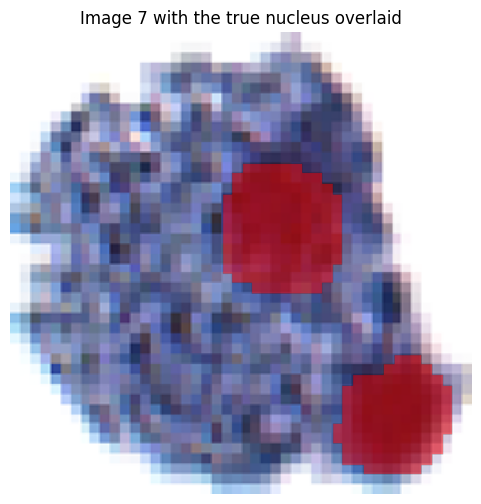

✅ Puzzle 4 solved!


In [17]:
nucleus_only = np.ma.masked_where(mask7 != 2, mask7)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img7_hwc)
ax.imshow(nucleus_only, cmap='autumn', alpha=0.5)
ax.set_title('Image 7 with the true nucleus overlaid')
ax.axis('off')
plt.show()

# ── Check ──
assert nucleus_only.count() == (mask7 == 2).sum(), "Only nucleus pixels should be left visible"
print("✅ Puzzle 4 solved!")

## 4. How Much of Each Class Is There?

Before building any model, check whether the classes are **balanced** (roughly equal in
size) or **skewed**.  Comparing `y == 2` gives an array of `True`/`False` values, and
`.sum()` counts the `True`s, because Python treats `True` as 1.

In [18]:
names = ['background', 'cytoplasm', 'nucleus']

print("Share of all pixels in the dataset:")
for label in [0, 1, 2]:
    count = (y == label).sum()
    print(f"  {label} {names[label]:>10}: {count:>10,} pixels  ({100 * count / y.size:.1f}%)")

Share of all pixels in the dataset:
  0 background:  4,714,960 pixels  (36.0%)
  1  cytoplasm:  5,823,720 pixels  (44.4%)
  2    nucleus:  2,568,520 pixels  (19.6%)


That is the dataset as a whole.  We also want the count **per image**.

### 🧩 Puzzle 5 — Nucleus pixels in every image

`(y == 2)` has shape `(200, 256, 256)`.  Sum over the right axes so that you are left with
**one number per image** — an array of shape `(200,)`.

📖 Book: [§1.3.3 The Concept of Axes: Stack and Collapse](https://obooks.tech/imageprocessing/chapter1.html#the-concept-of-axes-stack-and-collapse) and
[§1.4.4 Operations Across Multiple Axes](https://obooks.tech/imageprocessing/chapter1.html#operations-across-multiple-axes)

<details><summary><b>💡 Hint 1</b> (click to open)</summary>

Summing over an axis makes that axis disappear.  Which axes do you want to disappear, and which one should survive?

</details>

<details><summary><b>💡 Hint 2</b> (click to open)</summary>

You can collapse several axes at once by passing a tuple, e.g. `axis=(0, 1)`.

</details>

In [26]:
nuc_px = (y == 2).sum(axis=(1, 2))
cyt_px = (y == 1).sum(axis=(1, 2))

print("nuc_px shape:", nuc_px.shape)
print("Nucleus pixels in the first 5 images:", nuc_px[:5])
print("Images with NO nucleus at all:", (nuc_px == 0).sum())

# ── Check ──
assert nuc_px.shape == (200,), "You should have one count per image"
assert nuc_px[7] == (y[7] == 2).sum(), "nuc_px[7] should be the nucleus count of image 7"
print("✅ Puzzle 5 solved!")

nuc_px shape: (200,)
Nucleus pixels in the first 5 images: [ 4532 22388 15863 10550  8790]
Images with NO nucleus at all: 9
✅ Puzzle 5 solved!


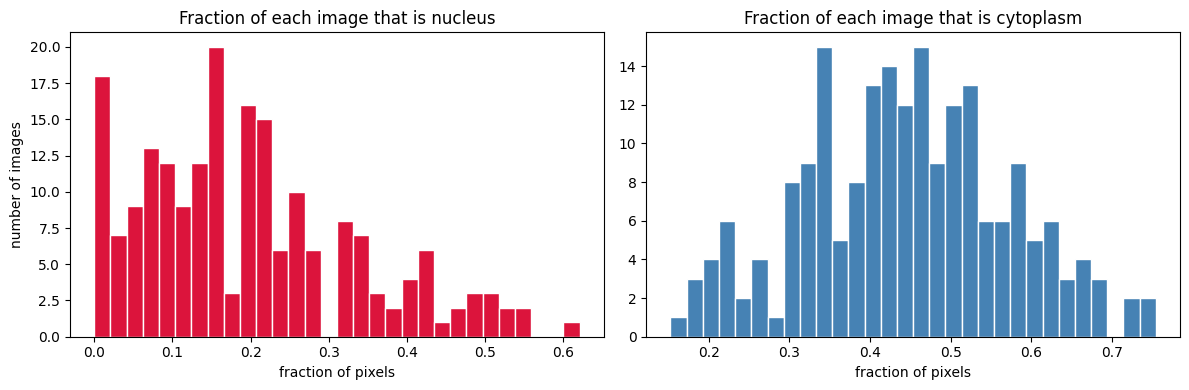

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(nuc_px / (256 * 256), bins=30, color='crimson', edgecolor='white')
axes[0].set_title('Fraction of each image that is nucleus')
axes[0].set_xlabel('fraction of pixels')
axes[0].set_ylabel('number of images')
axes[1].hist(cyt_px / (256 * 256), bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Fraction of each image that is cytoplasm')
axes[1].set_xlabel('fraction of pixels')
plt.tight_layout()
plt.show()

**Think about it:** some images contain no nucleus at all.  What would a segmenter's
"nucleus score" even mean for those images?  We will have to decide how to treat them
when we start measuring accuracy in Lab 2.

### 🧩 Puzzle 6 — The true N/C ratio

The quantity this course is all about:

$$\text{N/C ratio} = \frac{\text{number of nucleus pixels}}{\text{number of cytoplasm pixels}}$$

A high N/C ratio is a warning sign for cancer.  Finish the function, then use it on every
ground-truth mask.

📖 Book: [§1.2.3 Vectorized Operations](https://obooks.tech/imageprocessing/chapter1.html#vectorized-operations) and
[§1.2.4 Aggregation Functions](https://obooks.tech/imageprocessing/chapter1.html#aggregation-functions)

<details><summary><b>💡 Hint 1</b> (click to open)</summary>

Inside the function, count pixels exactly as in Puzzle 5, but on a single `(256, 256)` mask, so no `axis` is needed.

</details>

<details><summary><b>💡 Hint 2</b> (click to open)</summary>

Nucleus label is 2, cytoplasm label is 1.  Which count goes on top of the fraction?

</details>

True N/C ratio of image 7: 0.181


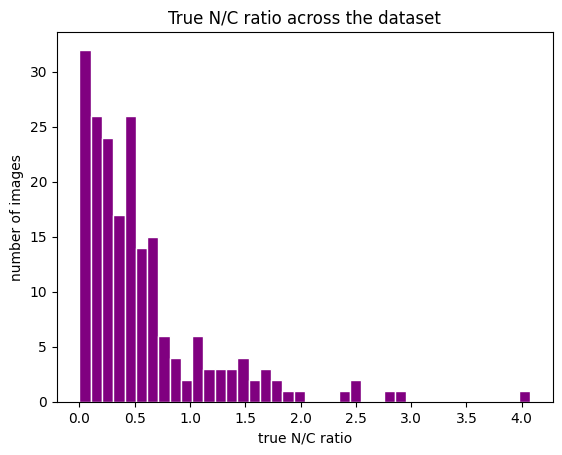

✅ Puzzle 6 solved!


In [28]:
def nc_ratio(mask):
    nucleus_pixels   = (mask == 2).sum()
    cytoplasm_pixels = (mask == 1).sum()
    return nucleus_pixels / cytoplasm_pixels

print(f"True N/C ratio of image 7: {nc_ratio(y[7]):.3f}")

nc_true = np.array([nc_ratio(y[i]) for i in range(200)])

plt.hist(nc_true, bins=40, color='purple', edgecolor='white')
plt.xlabel('true N/C ratio')
plt.ylabel('number of images')
plt.title('True N/C ratio across the dataset')
plt.show()

# ── Check ──
assert abs(nc_ratio(y[7]) - (y[7] == 2).sum() / (y[7] == 1).sum()) < 1e-9, "Nucleus on top, cytoplasm on the bottom"
print("✅ Puzzle 6 solved!")

### 🧩 Puzzle 7 — The average image and the average colour

Averaging over an axis squeezes the dataset into a summary.

- Averaging over the **image** axis gives the *average image*: shape `(3, 256, 256)`.
- Averaging over the image, row and column axes leaves **one number per channel**: shape `(3,)`.

📖 Book: [§1.5.7 Statistical Operations on 4D Arrays](https://obooks.tech/imageprocessing/chapter1.html#statistical-operations-on-4d-arrays)

<details><summary><b>💡 Hint 1</b> (click to open)</summary>

Recall the axis order of `X`: 0 = image, 1 = channel, 2 = row, 3 = column.

</details>

<details><summary><b>💡 Hint 2</b> (click to open)</summary>

To keep only the channel axis, you must average over every *other* axis.

</details>

mean_image shape:    (3, 256, 256)
Average R, G, B:     [0.684 0.689 0.769]


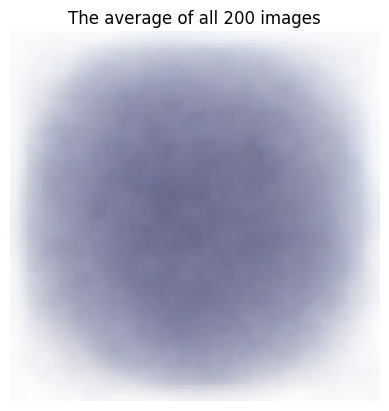

✅ Puzzle 7 solved!


In [30]:
mean_image    = X.mean(axis=0)
channel_means = X.mean(axis=(0, 2, 3))

print("mean_image shape:   ", mean_image.shape)
print("Average R, G, B:    ", channel_means.round(3))

plt.imshow(mean_image.transpose(1, 2, 0))
plt.title('The average of all 200 images')
plt.axis('off')
plt.show()

# ── Check ──
assert mean_image.shape == (3, 256, 256), "mean_image should look like one image"
assert channel_means.shape == (3,), "channel_means should hold one number per channel"
print("✅ Puzzle 7 solved!")

**Think about it:** what does the average image tell you about where the cells sit in each
picture?  Why might the blue channel have the highest average?  (Hint: what colour is most
of each image?)

## 5. Grayscale Conversion

Three numbers per pixel are more than we need to tell a dark nucleus from bright glass.
A **grayscale** image keeps one brightness value per pixel.  We do **not** simply average
R, G and B, because our eyes are most sensitive to green and least to blue.  The standard
**BT.601** formula weights the channels accordingly:

$$\text{gray} = 0.299 \cdot R \;+\; 0.587 \cdot G \;+\; 0.114 \cdot B$$

📖 Book: [§2.4.1 Manual Conversion: Luminance Weights](https://obooks.tech/imageprocessing/chapter2.html#manual-conversion-luminance-weights)

Here it is for image 7, using the channels from Puzzle 2:

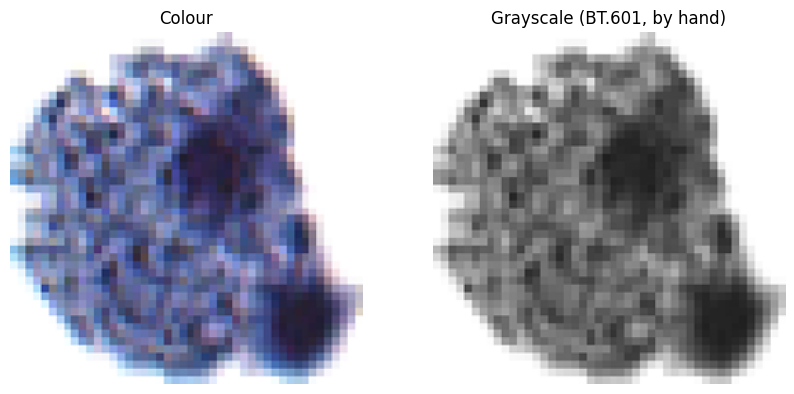

In [31]:
gray7 = 0.299 * R + 0.587 * G + 0.114 * B

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img7_hwc)
axes[0].set_title('Colour')
axes[1].imshow(gray7, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Grayscale (BT.601, by hand)')
for ax in axes:
    ax.axis('off')
plt.show()

### 🧩 Puzzle 8 — Grayscale for all 200 images at once

No loop needed!  `X[:, 0]` means "every image, channel 0" and has shape `(200, 256, 256)`.
Fill in the channel numbers so that one line converts the whole dataset.

📖 Book: [§1.5 Four-Dimensional Arrays](https://obooks.tech/imageprocessing/chapter1.html#four-dimensional-arrays-batch-processing) and
[§2.4.1 Manual Conversion](https://obooks.tech/imageprocessing/chapter2.html#manual-conversion-luminance-weights)

<details><summary><b>💡 Hint</b> (click to open)</summary>

The `:` keeps every image.  The number after the comma chooses the channel, just as in Puzzle 2.  Match each channel with its weight.

</details>

In [33]:
gray_all = 0.299 * X[:, 0] + 0.587 * X[:, 1] + 0.114 * X[:, 2]

print("gray_all shape:", gray_all.shape)

# ── Check ──
assert gray_all.shape == (200, 256, 256), "You should get one grayscale image per colour image"
assert np.allclose(gray_all[7], gray7), "gray_all[7] should match gray7 from the cell above"
print("✅ Puzzle 8 solved!")

gray_all shape: (200, 256, 256)
✅ Puzzle 8 solved!


Libraries can do this for us.  scikit-image's `rgb2gray` uses the newer **BT.709** weights
(0.2126, 0.7152, 0.0722) and expects the channel *last*.  How different is the result?

📖 Book: [§2.4.2 Using a Python Library](https://obooks.tech/imageprocessing/chapter2.html#using-a-python-library) and
[§2.4.3 BT.601 vs BT.709 — Does It Matter?](https://obooks.tech/imageprocessing/chapter2.html#bt.601-vs-bt.709-does-it-matter)

In [34]:
from skimage.color import rgb2gray

gray7_709 = rgb2gray(img7_hwc)

print("Largest difference between BT.601 and BT.709 on image 7:", np.abs(gray7_709 - gray7).max().round(4))

Largest difference between BT.601 and BT.709 on image 7: 0.0206


The difference is small.  What matters more is to **pick one formula and use it
everywhere** — for the rest of the course we use BT.601, the one we wrote by hand.

## 6. How Bright Is Each Class?

This is the most important question of the lab.  If nucleus, cytoplasm and background
pixels have clearly different brightness, then brightness alone could tell them apart.

A `True`/`False` array can be used *as an index*: `gray_all[y == 2]` keeps only the
grayscale values at nucleus pixels and returns them as a flat list of numbers.

### 🧩 Puzzle 9 — Brightness by class

Collect the grayscale values of every background, cytoplasm and nucleus pixel in the
dataset, then plot their histograms on the same axes.

📖 Book: [§2.5.3 Aggregating and Computing Statistics on Masked Regions](https://obooks.tech/imageprocessing/chapter2.html#aggregating-and-computing-statistics-on-masked-regions)
(a sneak peek — we use the ground-truth mask here, not a threshold)

<details><summary><b>💡 Hint 1</b> (click to open)</summary>

`gray_all` and `y` have the same shape, so `y == label` lines up pixel-for-pixel with `gray_all`.

</details>

<details><summary><b>💡 Hint 2</b> (click to open)</summary>

Background is 0, cytoplasm is 1, nucleus is 2.

</details>

background: mean = 0.997   std = 0.026   pixels = 4,714,960
 cytoplasm: mean = 0.637   std = 0.209   pixels = 5,823,720
   nucleus: mean = 0.279   std = 0.134   pixels = 2,568,520


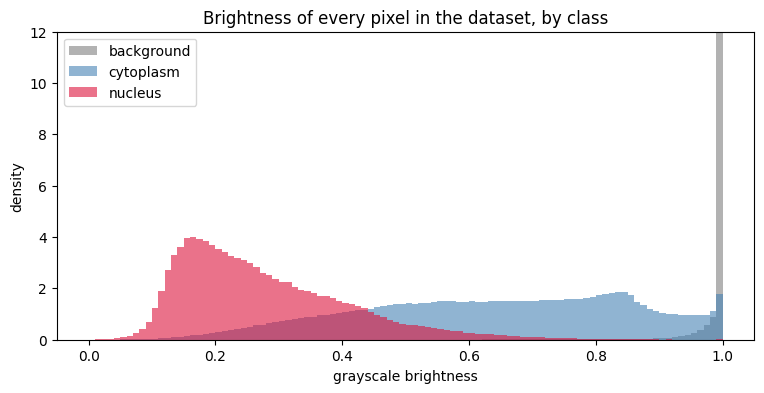

✅ Puzzle 9 solved!


In [35]:
background_vals = gray_all[y == 0]
cytoplasm_vals  = gray_all[y == 1]
nucleus_vals    = gray_all[y == 2]

for name, vals in [('background', background_vals), ('cytoplasm', cytoplasm_vals), ('nucleus', nucleus_vals)]:
    print(f"{name:>10}: mean = {vals.mean():.3f}   std = {vals.std():.3f}   pixels = {vals.size:,}")

plt.figure(figsize=(9, 4))
plt.hist(background_vals, bins=100, range=(0, 1), density=True, alpha=0.6, color='gray', label='background')
plt.hist(cytoplasm_vals,  bins=100, range=(0, 1), density=True, alpha=0.6, color='steelblue', label='cytoplasm')
plt.hist(nucleus_vals,    bins=100, range=(0, 1), density=True, alpha=0.6, color='crimson', label='nucleus')
plt.xlabel('grayscale brightness')
plt.ylabel('density')
plt.ylim(0, 12)
plt.legend()
plt.title('Brightness of every pixel in the dataset, by class')
plt.show()

# ── Check ──
assert nucleus_vals.size == (y == 2).sum(), "nucleus_vals should hold one value per nucleus pixel"
assert background_vals.mean() > cytoplasm_vals.mean() > nucleus_vals.mean(), "Check which label goes with which class"
print("✅ Puzzle 9 solved!")

(The background peak at 1.0 is so tall that we cut the plot off at 12 with `plt.ylim` so the
other two classes stay visible.)

## Wrap-up

**What we learned about the data:**
- `X` is a batch of 200 colour images in channels-first order `(image, channel, row, column)`;
  `y` holds one label per pixel.
- Cytoplasm is the largest class, then background, then nucleus.  A few images contain no
  nucleus at all.
- The true N/C ratio varies widely from image to image.
- The three classes have **different typical brightness**: background is almost pure white,
  cytoplasm is in the middle, and nucleus is darkest.  But the cytoplasm and nucleus
  histograms **overlap**.

---

### Before Lab 2 — make a prediction ✏️

Lab 2 turns the histogram above into a segmenter.  The idea: pick two brightness values,

- `t_nucleus` — anything darker than this is called **nucleus**;
- `t_background` — anything brighter than this is called **background**;
- anything in between is called **cytoplasm**.

1. Looking at the histogram, **write down your two numbers.**  You will test them at the
   start of Lab 2.
2. Where the cytoplasm and nucleus histograms overlap, some pixels will be labelled wrongly
   no matter what you choose.  Which class do you think will suffer more, and why?
3. In Section 2 you saw one channel where nuclei stood out more than in the others.  Is
   grayscale the best single channel for our job?  How could you test that?